# Sentiment Classification using Logistic Regression

Goal:

Train a sentiment classifier on the TF-IDF features.

Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

This model will become the NLP component of the Emotion + Sentiment Fusion Detector.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np

PROJECT_ROOT = "/content/drive/MyDrive/emotion_sentiment_fusion_detector"

X = np.load(
    f"{PROJECT_ROOT}/data/tfidf/X.npy"
)

y = np.load(
    f"{PROJECT_ROOT}/data/tfidf/y.npy"
)

print(X.shape)
print(y.shape)

(5000, 3000)
(5000,)


## Train Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 3000)
(1000, 3000)


## Train Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [6]:
train_acc = model.score(
    X_train,
    y_train
)

test_acc = model.score(
    X_test,
    y_test
)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.88525
Test Accuracy: 0.856


## Predictions

In [7]:
y_pred = model.predict(
    X_test
)

In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       506
           1       0.89      0.81      0.85       494

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



## Confusion Matrix

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[455,  51],
       [ 93, 401]])

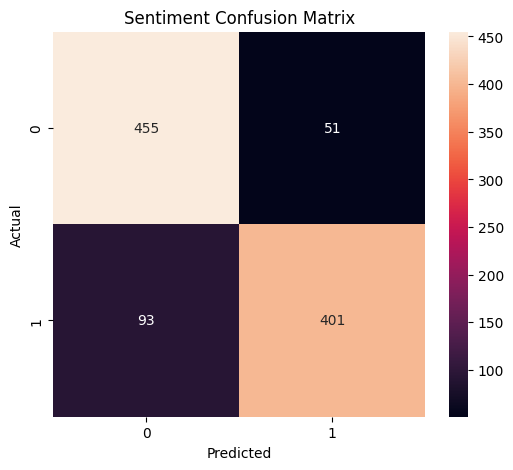

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Sentiment Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Precision, Recall, F1

In [11]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1:",
    f1_score(y_test, y_pred)
)

Precision: 0.8871681415929203
Recall: 0.8117408906882592
F1: 0.8477801268498943


## Example Predictions

In [12]:
indices = np.random.choice(
    len(X_test),
    10,
    replace=False
)

for idx in indices:

    print(
        "Actual:",
        y_test[idx]
    )

    print(
        "Predicted:",
        y_pred[idx]
    )

    print("-"*50)

Actual: 0
Predicted: 1
--------------------------------------------------
Actual: 0
Predicted: 0
--------------------------------------------------
Actual: 1
Predicted: 1
--------------------------------------------------
Actual: 1
Predicted: 1
--------------------------------------------------
Actual: 0
Predicted: 0
--------------------------------------------------
Actual: 1
Predicted: 0
--------------------------------------------------
Actual: 0
Predicted: 0
--------------------------------------------------
Actual: 1
Predicted: 1
--------------------------------------------------
Actual: 1
Predicted: 1
--------------------------------------------------
Actual: 1
Predicted: 1
--------------------------------------------------


In [13]:
import os

os.makedirs(
    f"{PROJECT_ROOT}/models/nlp",
    exist_ok=True
)

In [14]:
import joblib

joblib.dump(
    model,
    f"{PROJECT_ROOT}/models/nlp/logistic_regression_tfidf.pkl"
)

print("Model saved.")

Model saved.


In [15]:
os.listdir(
    f"{PROJECT_ROOT}/models/nlp"
)

['logistic_regression_tfidf.pkl']

# Sentiment Model Summary

Model:
- Logistic Regression

Input:
- TF-IDF vectors

Output:
- Positive sentiment
- Negative sentiment

Evaluation:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

This model forms the NLP branch of the Emotion + Sentiment Fusion Detector.

In [16]:
np.save(
    f"{PROJECT_ROOT}/data/tfidf/X_train.npy",
    X_train
)

np.save(
    f"{PROJECT_ROOT}/data/tfidf/X_test.npy",
    X_test
)

np.save(
    f"{PROJECT_ROOT}/data/tfidf/y_train.npy",
    y_train
)

np.save(
    f"{PROJECT_ROOT}/data/tfidf/y_test.npy",
    y_test
)